## Project Objective

The objective of this project is to develop a machine learning model for automatic sentiment classification of Russian-language texts.

The project covers the complete NLP workflow, from loading and exploring the dataset to text preprocessing, feature extraction using TF-IDF, model training, and performance evaluation.

The following tasks will be completed as part of the project:

- exploring the structure and quality of the dataset;
- analyzing the distribution of target classes;
- preparing text data for machine learning;
- transforming text into numerical features using TF-IDF;
- training a Logistic Regression model for sentiment classification;
- evaluating model performance using Accuracy, Precision, Recall, and F1-score;
- analyzing the Confusion Matrix;
- examining examples where the model makes incorrect predictions;
- testing the trained model on new user-provided texts;
- experimenting with vectorization parameters and comparing model performance.

The final result will be a model capable of receiving a new text as input and predicting its sentiment, along with an analysis of the factors that influence classification performance.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

In [4]:
# import dataset
dataset = load_dataset("ai-forever/kinopoisk-sentiment-classification")
print(dataset)
print(dataset["train"].features['label_text'])
dataset["train"].unique("label_text")

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 10500
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 1500
    })
})
Value('string')


['Good', 'Bad', 'Neutral']

In [5]:
# EDA
train_df = dataset['train'].to_pandas()
train_df.head(5)

,id,text,label,label_text
0,0,"Если честно, меня не очень впечатлила новость,...",2,Good
1,1,"Сразу скажу — книгу я не читала, поэтому о том...",0,Bad
2,2,Общее впечатление таково: фильм не назовешь пл...,1,Neutral
3,3,Только что посмотрела этот «фильм». Рецензии п...,0,Bad
4,4,"Скажу сразу же, фильм — гениален! Если есть те...",2,Good


In [7]:
# convert the training split to a pandas DataFrame
train_df = dataset['train'].to_pandas()

In [8]:
# show the first 5 rows
train_df.head(5)

,id,text,label,label_text
0,0,"Если честно, меня не очень впечатлила новость,...",2,Good
1,1,"Сразу скажу — книгу я не читала, поэтому о том...",0,Bad
2,2,Общее впечатление таково: фильм не назовешь пл...,1,Neutral
3,3,Только что посмотрела этот «фильм». Рецензии п...,0,Bad
4,4,"Скажу сразу же, фильм — гениален! Если есть те...",2,Good


In [9]:
# inspect the dataset features
dataset["train"].features

{'id': Value('string'),
 'text': Value('string'),
 'label': Value('int64'),
 'label_text': Value('string')}

In [10]:
# store the column names in variables, so the rest of the notebook does not depend on hard-coded strings.
TEXT_COL = train_df['text']
LABEL_COL = train_df['label_text']

print(TEXT_COL.head(5))
print('-'*100)
print(LABEL_COL.head(5))

0    Если честно, меня не очень впечатлила новость,...
1    Сразу скажу — книгу я не читала, поэтому о том...
2    Общее впечатление таково: фильм не назовешь пл...
3    Только что посмотрела этот «фильм». Рецензии п...
4    Скажу сразу же, фильм — гениален! Если есть те...
Name: text, dtype: str
----------------------------------------------------------------------------------------------------
0       Good
1        Bad
2    Neutral
3        Bad
4       Good
Name: label_text, dtype: str


In [11]:
# find the unique values of the target column
LABEL_COL.unique()

<ArrowStringArray>
['Good', 'Bad', 'Neutral']
Length: 3, dtype: str

In [12]:
# count how many samples belong to each class
class_сounts = LABEL_COL.value_counts()

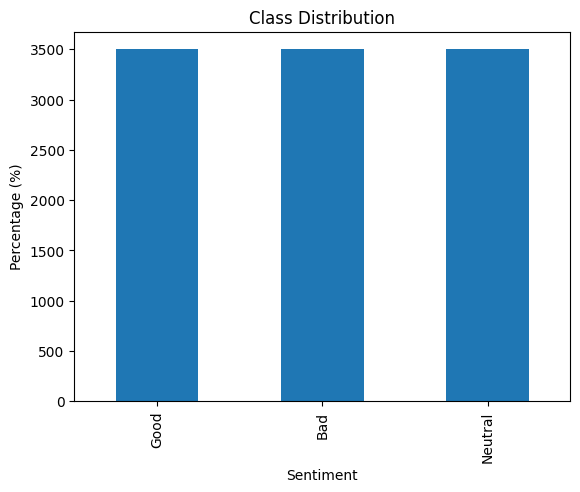

In [13]:
# check class balance
# Print the proportion of each class and draw a bar chart.

class_сounts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.show()

In [14]:
# look for missing values in the text and label columns
train_df.isna().sum()

id            0
text          0
label         0
label_text    0
dtype: int64

In [15]:
# print a few full reviews of each class.
print(LABEL_COL[0].upper())
print(TEXT_COL[0])
print('-'*100)
print(LABEL_COL[1].upper())
print(TEXT_COL[1])
print('-'*100)
print(LABEL_COL[2].upper())
print(TEXT_COL[2])

GOOD
Если честно, меня не очень впечатлила новость, о том, что Гай Ричи собирается снять фильм, о Шерлоке Холмсе. Подумал — да это же будет: Карты, деньги, два ствола — у Холмса и у Ватсона. Но затем по мере появления трейлеров, и большей информации поменял своё отношение.
«Шерлок Холмс» — последняя картина, на которую я планировал пойти в этом году. Жутко боялся, что она меня разочарует т. к. перед этим были расстроившие «Безумный спецназ», «Так себе каникулы» и немного 2012. Но Холмс полностью оправдал доверия.
Сюжет
В ленте динамичный, а главное интересный и захватывающий сюжет, что в последнее время не так уж и часто. Новый Холмс не поход классический образ представленный в картинах Игоря Масленникова, но это не портит его образ. Он больше подобен на Тони Старку из «Железного человека» или Грегори Хаусу из сериала «Доктор Хаус». Как и они, он весьма харизматичен, слегка безумен, но гениален в своём любимом деле.
На первый взгляд сюжет портит сверхъестественное восстание из могилы л

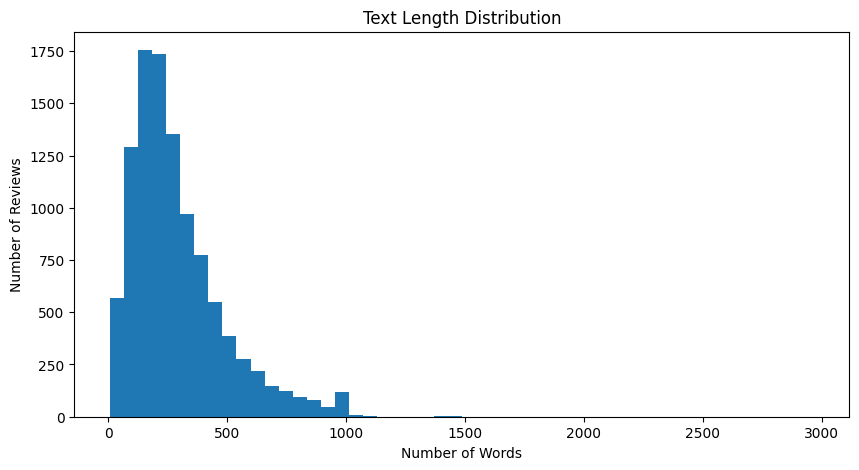

In [16]:
# print a text length of each class.
train_df["text_length"] = TEXT_COL.str.split().str.len()
plt.figure(figsize=(10, 5))

plt.hist(train_df["text_length"], bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

In [17]:
# print duplicates
train_df["text"].duplicated().sum()

np.int64(0)

In [18]:
train_df["text_length"].describe()

count    10500.000000
mean       288.452190
std        199.116615
min          5.000000
25%        151.000000
50%        239.000000
75%        373.250000
max       2969.000000
Name: text_length, dtype: float64